# CH09. 자연어 전처리
## 9.1 자연어 처리란
자연어 처리란 우리가 일상생활에서 사용하는 언어 의미를 분석하여 컴퓨터가 처리할 수 있도록 하는 과정입니다. 자연어 처리는 딥러닝에 대한 이해도 필요하지만, 그에 앞서 인간 언어에 대한 이해도 필요하기 때문에 접근하기 어려운 분야입니다. 또한, 언어 종류가 다르고 그 형태가 다양하기 때문에 처리가 매우 어렵습니다. 예를 들어 영어는 명확한 띄어쓰기가 있지만, 중국어는 띄어쓰기가 없기 때문에 단어 단위의 임베딩이 어렵습니다. 또한, 자연어 처리를 위해 사용되는 용어들도 낮섭니다.

다음 그림은 자연어 처리가 가능한 영역과 발전이 필요한 분야입니다. 예를 들어 스팸 처리 및 맞춤법 검사는 완성도가 높은 반면, 질의응답 및 대화는 아직 발전이 더 필요한 분야입니다.

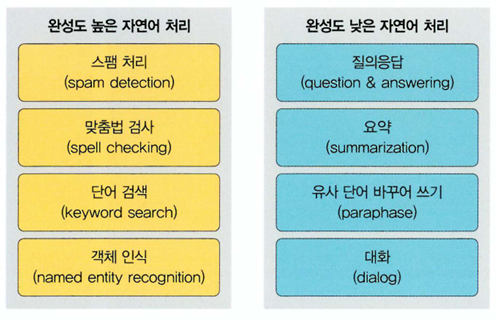

자연어 처리에서 사용하는 용어부터 알아보겠습니다.

### 9.1.1 자연어 처리 용어 및 과정
자연어 처리 관련 용어와 처리 과정을 먼저 알아보겠습니다.

**자연어 처리 관련 용어**
- 말뭉치(corpus(코퍼스)): 자연어 처리에서 모델을 학습시키기 위한 데이터이며, 자연어 연구를 위해 특정한 목적에서 표본을 추출한 집합입니다.
- 토큰(token): 자연어 처리를 위한 문서는 작은 단위로 나누어야 하는데, 이때 문서를 나누는 단위가 토큰입니다. 문자열을 토큰으로 나누는 작업을 토큰생성(tokenizing)이라고하며, 문자열을 토큰으로 분리하는 함수를 토큰 생성 함수라고 합니다.
- 토큰화(tokenization): 텍스트를 문장이나 단어로 분리하는 것을 의미합니다. 토큰화 단계를 마치면 텍스트가 단어 단위로 분리됩니다.
- 불용어(stop words): 문장 내에서 많이 등장하는 단어입니다. 분석과 관계없으며, 자주 등장하는 빈도 때문에 성능에 영향을 미치므로 사전에 제거해 주어야 합니다. 불용어 예로 "a", "the", "she", "he" 등이 있습니다.
- 어간 추출(stemming): 단어를 기본 형태로 만드는 작업입니다. 예를 들어 'consign', 'consigned', 'consigning', 'consignment'가 있을 때 기본 단어인 'consign'으로 통일하는 것이 어간추출입니다.
- 품사 태깅(part-of-speech tagging): 주어진 문장에서 품사를 식별하기 위해 붙여 주는 태그(식별 정보)를 의미합니다.

품사 태깅을 위한 정보는 다음과 같습니다.
- Det: 한정사
- Noun: 명사
- Verb: 동사
- Prep: 전치사

품사 태깅은 NLTK를 이용할 수 있습니다.

품사 태깅을 위해 주어진 문장에 대해 토큰화를 먼저 진행합니다. 다음 코드를 실행하면 NLTK Downloader 창이 몹니다. Download를 눌러 내려받습니다.

In [2]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
text = nltk.word_tokenize("Is it possible distinguishing cats and dogs")
text

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Is', 'it', 'possible', 'distinguishing', 'cats', 'and', 'dogs']

태깅에 필요한 자원을 내려받습니다.

In [3]:
nltk.download('averaged_perceptron_tagger_eng') # 태깅에 필요한 자원 내려받기

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

내려받은 자원을 이용하여 품사를 태깅합니다.

In [4]:
nltk.pos_tag(text)

[('Is', 'VBZ'),
 ('it', 'PRP'),
 ('possible', 'JJ'),
 ('distinguishing', 'VBG'),
 ('cats', 'NNS'),
 ('and', 'CC'),
 ('dogs', 'NNS')]

여기서 사용되는 품사 의미는 다음과 같습니다.
- VBZ: 동사, 동명사 또는 현재 분사
- PRP: 인칭 대명사(PP)
- JJ: 형용사
- VBG: 동사, 동명사 또는 현재 분사
- NNS: 명사, 복수형
- CC: 등위 접속사

**자연어 처리 과정**
자연어는 인간 언어입니다. 인간 언어는 컴퓨터가 이해할 수 없기 때문에 컴퓨터가 이해할 수 있는 언어로 바꾸고 원하는 결괴를 얻기까지 크게 네 단계를 거칩니다.

첫 번째로 인간 언어인 자연어가 입력 텍스트로 들어오게 됩니다. 이때 인간 언어가 다양하듯 처리 방식이 조금씩 다르며, 현재는 영어에 대한 처리 방법들이 잘 알려져 있습니다.

두 번째로는 입력된 텍스트에 대한 전처리 과정이 필요합니다.

세 번째로 전처리가 끝난 단어들을 임베딩합니다. 즉 단어를 벡터로 변환하는 방법입니다.

마지막으로 컴퓨터가 이해할 수 있는 데이터가 완성되었기 때문에 모델/모형을 이용하여 데이터에 대한 분류 및 예측을 수행합니다. 이때 데이터 유형에 따라 분류와 예측에 대한 결과가 달라집니다.

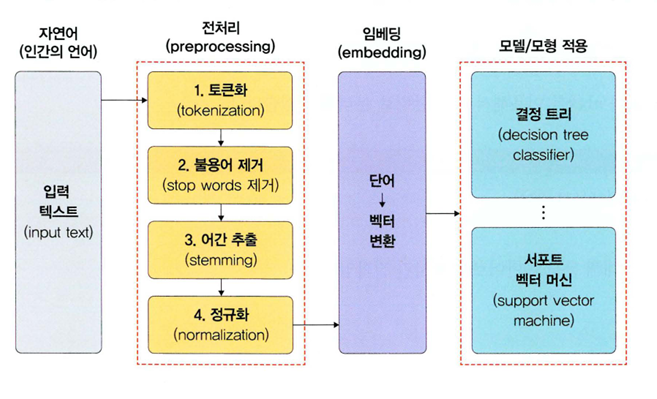

### 9.1.2 자연어 처리를 위한 라이브러리
**NLTK**
NLTK는 교육용으로 개발된 자연어 처리 및 문서 분석용 파이썬 라이브러리입니다. 다양한 기능 및 예제를 가지고 있으며 실무 및 연구에서도 많이 사용되고 있습니다.

다음은 NLTK 라이브러리가 제공하는 주요 기능입니다.
- 말뭉치
- 토큰 생성
- 형태소 분석
- 품사 태깅
설치한 NLTK 라이브러리를 이용하여 예제를 살펴보겠습니다.

In [5]:
import nltk
nltk.download('punkt') # 문장을 단어로 쪼개기 위한 자원 내려받기
string1 = "my favorite subject is math"
string2 = "my favorite subject is math, english, economic and computer science"
nltk.word_tokenize(string1)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['my', 'favorite', 'subject', 'is', 'math']

이번에는 string2를 nltk를 이용해서 단어 단위로 분리해 보겠습니다.

In [6]:
nltk.word_tokenize(string2)

['my',
 'favorite',
 'subject',
 'is',
 'math',
 ',',
 'english',
 ',',
 'economic',
 'and',
 'computer',
 'science']

**KoNLPy**
KoNLPy는 한국어 처리를 위한 파이씬 라이브러리입니다. KoNLPy는 파이씬에서 사용할 수 있는 오픈 소스 형태소 분석기로, 기존에 공개된 꼬꼬마(Kkma), 코모란 (Komoran), 한나눔(Hannanurn), 트위터(Twitter), 메카브(Mecab) 분석기를 한 번에 설치하고 동일한 방법으로 사용할 수 있도록 해 줍니다.



In [11]:
from konlpy.tag import Komoran
komoran = Komoran()
print(komoran.morphs('딥러닝이 쉽나요? 어렵나요?')) # 텍스트를 형태소로 변환

['딥러닝이', '쉽', '나요', '?', '어렵', '나요', '?']


이번에는 문장을 형태소로 변환한 후 품사를 태깅해 보겠습니다.

In [12]:
print(komoran.pos('소파 위에 있는 것이 고양이인가요? 강아지인가요?')) # 텍스트에서 품사를 태깅하여 반환

[('소파', 'NNP'), ('위', 'NNG'), ('에', 'JKB'), ('있', 'VV'), ('는', 'ETM'), ('것', 'NNB'), ('이', 'JKS'), ('고양이', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF'), ('강아지', 'NNG'), ('이', 'VCP'), ('ㄴ가요', 'EF'), ('?', 'SF')]


KoNLPy에서 제공하는 주요 기능은 다음과 같습니다.
- 형태소 분석
- 품사 태깅

**Gensim**
Gensim은 파이썬에서 제공하는 워드투벡터 라이브러리입니다. 딥러닝 라이브러리는 아니지만 효율적이고 확장 가능하기 때문에 폭넓게 사용하고 있습니다.

다음은 Gensim에서 제공하는 주요 기능입니다.
- 임베딩: 워드투벡터
- 토픽 모델링
- LDA(Latent Dirchlet Allocation)

**사이킷런**
사이킷런은 파이썬을 이용하여 문서를 전처리할 수 있는 라이브러리를 제공합니다. 특히 자연어 처리에서 특성 추출 용도로 많이 사용됩니다.

다음은 사이킷런에서 제공하는 주요 기능입니다.
- CountVectorizer: 텍스트에서 단어의 등장 횟수를 기준으로 특성을 추출합니다.
- Tfidfvectorizer: TF-IF 값을 사용해서 텍스트에서 특성을 추출합니다.
- HashingVectorizer: CountVectorizer와 방법이 동일하지만 텍스트를 처리할 때 해시 함수를 사용하기 때문에 실행 시간이 감소합니다.

# CH13. 생성 모델
## 13.1 생성 모델이란
생성 모델은 주어진 데이터를 학습하여 데이터 분포를 따르는 유사한 데이터를 생성하는 모델입니다. 그럼 유사한 데이터는 어떻게 만들고, 생성 모델의 유형은 어떤 것들이 있는지 알아보겠습니다.

### 13.1.1 생성 모델 개념
기존 합성곱 신경망에서 다룬 이미지 분류 이미지 검출 등은 입력 이미지(x)가 있을 때 그에 따른 정답(y)을 찾는 것이었습니다. 예를 들어 개와 고양이 이미지 데이터셋이 주어졌을 때, 그 이미지를 개와 고양이로 분류하는 문제들을 다루었습니다. 이렇게 이미지를 분류하는 것을 '판별(자) 모델(discriminative model)'이라고 합니다. 일반적으로 판별자 모델에서는 이미지를 정확히 분류(구별)하고자 해당 이미지를 대표하는 특성들을 잘 찾는 것을 목표로 합니다. 예를 들어 개와 고양이를 구별하려면 개의 귀 꼬리 등 특성을 찾는 것이 중요합니다.

그리고 판별자 모벨에서 추출한 특성들의 조합을 이용하여 새로운 개와 고양이 이미지를 생성할 수 있는데, 이것을 '생성(자) 모델(generative model)'이라고 합니다. 즉, 생성 모델은 입력 이미지에 대한 데이터 분포p(x)를 학습하여 새로운 이미지(새로운 이미지이면서 기존 이미지에서 특성을 추출했기 때문에 최대한 입력 이미지와 유사한 이미지)를 생성하는 것을 목표로 합니다.

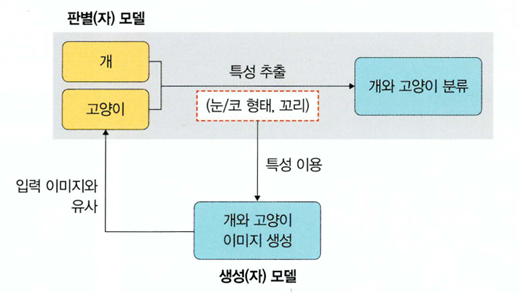

### 13.1.2 생성 모델의 유형
생성 모델의 유형에는 다음 그림과 같이 모델의 확률 변수를 구하는 '변형 오토인코더 모델'과 확률 변수를 이용하지 않는 'GAN 모델'이 있습니다.
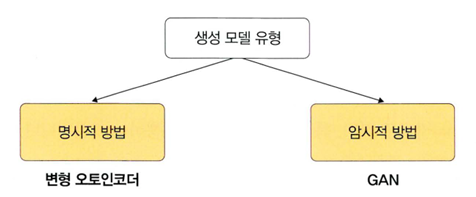

다시 정리하면 생성 모댈은 크게 명시적 방법과 암시적 방법으로 분류할 수 있습니다. 명시적 방법은 확률 변수p(x)를 정의하여 사용합니다. 대표적인 모델로 변형 오토인코더가 있습니다. 암시적 방법은 확률 변수p(x)에 대한 정의 없이 p(x)를 샘플링하여 사용합니다. 대표적인 모댈로 GAN(Generative Adversarial Network)이 있습니다.

변형 오토인코더는 이미지의 잠재 공간에서 샘플링하여 완전히 새로운 이미지나 기존 이미지를 변형하는 방식으로 학습을 진행합니다. GAN은 생성자와 판별자가 서로 경쟁하면서 가짜 이미지를 진짜 이미지와 최대한 비슷하게 만들도록 학습을 진행합니다.

변형 오토인코더부터 살펴보겠습니다.

## 13.2 변형 오토인코더
변형 오토인코더는 오토인코더의 확장입니다. 따라서 오토인코더가 무엇인지 확인한 후 변형 오토인코더로 넘어가겠습니다.

### 13.2.1 오토인코더란
오토인코더는 단순히 입력을 출력으로 복사하는 신경망으로 은닉층(혹은 병목층이라고도 함)의 노드 수가 입력 값보다 적은 것이 특징입니다. 따라서 입력과 출력이 동일한 이미지라고 예상할 수 있습니다. 하지만 왜 입력을 출력으로 복사하는 방법을 사용할까요? 바로 은닉층 때문입니다. 오토인코더의 병목층은 입력과 출력의 뉴런보다 훨씬 적습니다. 즉, 적은 수의 병목층 뉴런으로 데이터를 가장 잘 표현할 수 있는 방법이 오토인코더입니다. 오토인코더는 네 가지 주요 부분으로 구성됩니다.

1. 인코더: 인지 네트워크라고도 하며, 특성에 대한 학습을 수행하는 부분입니다.
2. 병목층(은닉층): 모델의 뉴런 개수가 최소인 계층입니다. 이 계층에서는 차원이 가장 낮은 입력 데이터의 압충 표현이 포함됩니다.
3. 디코더: 생성 네트워크라고도 하며, 이 부분은 병목층에서 압축된 데이터를 원래대로 재구성하는 역할을 합니다. 즉, 최대한 입력에 가까운 출력을 생성하도록 합니다.
4. 손실 재구성: 오토인코더는 다음 그림과 같이 입력층과 출력층의 뉴런 개수가 동일하다는 것만 제외하면 일반적인 다층 퍼셉트론과 구조가 동일합니다. 오토인코더는 압축된 입력을 출력층에서 재구성하며, 손실 함수는 입력과 출력(인코더와 디코더)의 차이를 가지고 계산합니다.

오토인코더 개념을 이해했다면 이번에는 수학적으로 접근해 보겠습니다.

입력 x와 출력 y는 같은 차원(Rd)에 존재한다는 가정하에 입력 데이터를 인코더 네트워크에 통과시켜 압축된 잠재 벡터 z 값을 얻습니다. 이때 Z를 구하는 공식은 다음과 같습니다.

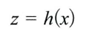

압축된z 벡터에서 입력 데이터와 크기가 같은 출력 값은 다음과 같이 계산합니다.

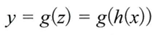

이때 손실 값은 입력 값x와 디코더를 통과한y 값의 차이로 다음과 같이 계산합니다.

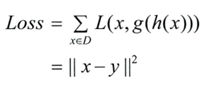

즉， 디코더 네트워크를 통과한 출력 값은 입력 값의 크기와 같이야 합니다.

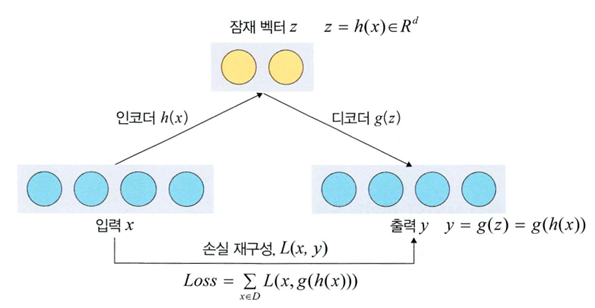

오토인코더가 중요한 이유는 다음 세 가지 때문입니다.

1. 데이터 압축: 데이터 압축은 메모리 측면에서 상당한 장점입니다. 오토인코더를 이용하여 이미 지나 음성 파일의 중요 특성만 압축하면 용량도 작고 품질도 더 좋아집니다.

2. 차원의 저주 예방: 차원의 저주 문제를 예방할 수 있습니다. 오토인코더는 특성 개수를 줄여 주기 때문에 데이터 차원이 감소하여 차원의 저주를 피할 수 있습니다.

3. 특성 추출: 오토인코더는 비지도 학습으로 자동으로 중요한 특성을 찾아 줍니다. 예를 들어 눈 모양, 털 색, 꼬리 길이 등 개의 중요한 특성을 자동으로 찾아 줍니다.

이제 파이토치에서 오토인코더를 구현해 보겠습니다.

예제는 다음 그림과 같은 구조의 오토인코더를 사용합니다.

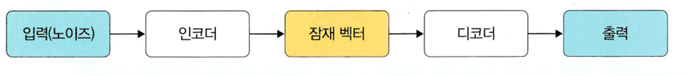

먼저 필요한 라이브러리를 호출합니다.

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

이 예제는 케라스에 내장되어 제공하는 MNIST 데이터셋을 사용합니다.

MNIST 데이터셋을 내려받은 후 텐서로 변경하고 데이터로더에 전달합니다.

In [16]:
transform = transforms.Compose([transforms.ToTensor()]) # transforms.ToTensor()는 이미지를 파이토치의 텐서 형태로 변형시켜 줍니다.

train_dataset = datasets.MNIST(root='080289/chap13/data', train=True, download=True, transform=transform) # MNIST를 내려받은 후 텐서 형태로 변형

test_dataset = datasets.MNIST(root='080289/chap13/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size = 128, shuffle = True, num_workers=4, pin_memory=False) # 1

test_loader = DataLoader(test_dataset, batch_size = 128, shuffle = False, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


1. 데이터로더는 전체 데이터셋을 작은 단위로 쪼개서 메모리로 가져올 때 사용합니다. 데이터로더에서 사용하는 파라미터는 다음과 같습니다.

a. 첫 번째 파라미터: 훈련 데이터셋
b. batch_size: 메모리로 한 번에 불러올 데이터의 크기
c. shuffle: True로 지정하면 데이터를 무작위로 섞겠다는 의미입니다.
d. num_workers: 데이터를 불러올 때 몇 개의 프로세스를 사용할지 지정하는 부분으로 병렬로 데이터를 불러오겠다는 의미입니다. 일반적으로 GPU를 사용할 때 많이 사용하는 파라미터입니다. 너무 많은 값을 할당하면 오버헤드가 발생할 수 있고 작게 할당하면 좋은 성능을 기대할 수 있으므로 적절한 값을 지정해야 합니다. 일반적으로 '4 * GPU 개수'를 지정하지만 모든 상황에 적합한 것은 아니므로 주의해서 시용할 필요가 있습니다.
e. pin_memory: CPU를 사용하다 GPU로 전환할 때 속도 향상을 위해 사용합니다. 따라서 모델 훈련 과정에서 CPU나 GPU만 사용한다면 True로 지정할 필요가 없는 파라미터입니다. pin_memory를 True로 지정하면 훈련에 사용할 데이터셋을 GPU에 미리 불러와서 학습시키기 때문에 속도가 향상됩니다.

이제 모델의 네트워크를 생성해 볼 멘데 인코더와 디코더를 사용하여 간단한 오토인코더를 만들어 봅시다. 이때 데이터셋을 저차원으로 압축하는 것을 인코더라고 하며, 압축된 것을 다시 원래의 차원으로 복원하는 것을 디코더라고 합니다. 따라서 인코더와 디코더에서 사용하는 네트워크 계층은 같아야합니다.

In [17]:
class Encoder(nn.Module): # 인코더 네트워크 생성
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()

    self.encoder_cnn = nn.Sequential(
        nn.Conv2d(1, 8, 3, stride = 2, padding = 1),
        nn.ReLU(True),
        nn.Conv2d(8, 16, 3, stride = 2, padding = 1),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.Conv2d(16, 32, 3, stride = 2, padding = 0),
        nn.ReLU(True)
    ) # 이미지 데이터셋 처리를 위해 합성곱 신경망 이용

    self.flatten = nn.Flatten(start_dim = 1) # 완전연결층
    self.encoder_lin = nn.Sequential(
        nn.Linear(3*3*32, 128),
        nn.ReLU(True),
        nn.Linear(128, encoded_space_dim)
    ) # 출력 계층

  def forward(self, x):
    x = self.encoder_cnn(x)
    x = self.flatten(x)
    x = self.encoder_lin(x)
    return x

class Decoder(nn.Module): # 디코더 네트워크 생성
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super().__init__()
    self.decoder_lin = nn.Sequential(
        nn.Linear(encoded_space_dim, 128),
        nn.ReLU(True),
        nn.Linear(128, 3*3*32),
        nn.ReLU(True)
    ) # 인코더의 출력을 디코더의 입력으로 사용

    self.unflatten = nn.Unflatten(dim=1,
                                  unflattened_size=(32, 3, 3)) # 인코더의 완전연결층에 대응
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(32, 16, 3, stride = 2, output_padding = 0),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.ConvTranspose2d(16, 8, 3, stride = 2, padding = 1, output_padding = 1),
        nn.BatchNorm2d(8),
        nn.ReLU(True),
        nn.ConvTranspose2d(8, 1, 3, stride = 2, padding = 1, output_padding = 1)
    ) # 인코더의 합성곱층에 대응

  def forward(self, x):
    x = self.decoder_lin(x)
    x = self.unflatten(x)
    x = self.decoder_conv(x)
    x = torch.sigmoid(x)
    return x

인코더와 디코더 객체를 초기화하고, 모델의 훈련 과정에 필요한 손실 함수와 옵티마이저를 지정합니다.

In [18]:
encoder = Encoder(encoded_space_dim = 4, fc2_input_dim = 128)
decoder = Decoder(encoded_space_dim = 4, fc2_input_dim = 128)
encoder.to(device)
decoder.to(device)

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
] # 인코더와 디코더에서 사용할 파라미터를 다르게 지정
optim = torch.optim.Adam(params_to_optimize, lr=0.001, weight_decay = 1e-05)
loss_fn = torch.nn.MSELoss()

오토인묘더에서 가장 널리 시용되는 손실 함수는 '평균 제곱 오차'와 '이진 크로스 엔트로피'입니다. 입력 값이 (0,1) 범위에 있으면 이진 크로스 엔트로피를 사용하고， 그렇지 않으면 평균 제곱 오치를 사용합니다. 옵티마이저는 아담을 사용했지만 알엠에스프롭 또는 아다델타 같은 옵티마이저를 이용하여 성능을 비교해 보는 것도 학습에 도움이 많이 되니, 옵션을 변경하여 테스트를 진행해 보기 바랍니다.

모델 학습에 대한 함수를 생성합니다.

In [19]:
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
  encoder.train() # 인코더 훈련
  decoder.train() # 디코더 훈련
  train_loss = []
  for image_batch, _ in dataloader: # 훈련 데이터셋을 이용하여 모델 학습(비지도 학습으로 레이블은 필요하지 않습니다)
    image_noisy = add_noise(image_batch, noise_factor)
    image_noisy = image_noisy.to(device) # 데이터셋이 CPU/GPU 장치를 사용하도록 지정
    encoded_data = encoder(image_noisy) # 노이즈 데이터를 인코더의 입력으로 사용
    decoded_data = decoder(encoded_data) # 인코더 출력을 디코더의 입력으로 사용
    loss = loss_fn(decoded_data, image_noisy)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.detach().cpu().numpy())
  return np.mean(train_loss)

이제 모델을 검증(테스트)하기 위한 함수를 생성합니다.

In [20]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
  # Set evaluation mode for encoder and decoder
  encoder.eval() # 인코더 테스트
  decoder.eval() # 디코더 데스트
  with torch.no_grad():
    conc_out = [] # 각 배치에 대한 출력을 저장하기 위해 리스트 형식의 변수 정의
    conc_label = []
    for image_batch, _ in dataloader:
      image_batch = image_batch.to(device)
      encoded_data = encoder(image_batch)
      decoded_data = decoder(encoded_data)
      conc_out.append(decoded_data.cpu())
      conc_label.append(image_batch.cpu())
    conc_out = torch.cat(conc_out) # 리스트 형식으로 저장된 모든 값을 하나의 텐서로 생성
    conc_label = torch.cat(conc_label)
    val_loss = loss_fn(conc_out, conc_label) # 손실 함수를 이용하여 오차 계산
  return val_loss.data

입력 데이터셋에 추가할 노이즈를 생성하기 위한 함수를 정의합니다.

In [21]:
def add_noise(inputs, noise_factor=0.3):
  noisy = inputs + torch.randn_like(inputs) * noise_factor # 1
  noisy = torch.clip(noisy, 0., 1.) # 2
  return noisy

1. torch.randn_like(inputs)는 입력과 동일한 크기의 노이즈 텐서를 생성하고자 할 때 사용합니다.
2. torch.clip은 데이터 값의 범위를 조정할 때 사용합니다.

파이씬에서 한글을 출력하면 한글이 깨지는 현상이 발생할 수 있습니다. 다음은 한글 깨짐 현상을 해결하기 위한 코드입니다. 경로 변경 없이 그대로 사용하세요.

In [22]:
!apt-get -qq install fonts-nanum

import matplotlib.pyplot as plt

import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

font_family = fm.FontProperties(fname=font_path).get_name()

plt.rcParams['font.family'] = font_family

Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


에포크가 진행될수록 노이즈 데이터로 새로운 이미지가 어떻게 만들어지는지 확인하기 위한 함수를 생성합니다. 시각화하여 보여 줄 이미지는 원래의 이미지 노이즈가 적용되어 손상된 데이터(이미지), 노이즈 데이터를 이용하여 새롭게 생성된 데이터(이미지)입나다.

In [23]:
def plot_ae_outputs(encoder, decoder, n=5, noise_factor=0.3):
  plt.figure(figsize = (10, 4.5))
  for i in range(n):
    ax = plt.subplot(3, n, i+1) # subplot에서 사용하는 파라미터는 (행, 열, 인덱스)입니다. 3x5 형태의 이미지가 출력됩니다.
    img = test_dataset[i][0].unsqueeze(0)
    image_noisy = add_noise(img, noise_factor)
    image_noisy = image_noisy.to(device)

    encoder.eval()
    decoder.eval()
    with torch.no_grad():
      rec_img = decoder(encoder(image_noisy))

    plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray') # 테스트 데이터셋을 출력
    ax.get_xaxis().set_visible(False) # set_visible(False)는 그래프의 눈금을 표시하지 않겠다는 의미
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('원래 이미지')
    ax = plt.subplot(3, n, i+1+n)
    plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray') # 테스트 데이터셋에 노이즈가 적용된 결과를 출력
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if 1 == n//2:
      ax.set_title('노이즈가 적용되어 손상된 이미지')

    ax = plt.subplot(3, n, i+1+n+n)
    plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray') # 노이즈가 추가된 이미지를 인코더와 디코더에 적용한 결과를 출력
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('재구성된 이미지')
  plt.subplots_adjust(left =0.1, bottom=0.1, right=0.7,
                      top=0.9, wspace = 0.3, hspace = 0.3) # subplots_adjust()를 이용하여 subplot들이 겹치지 않도록 최소한의 여백을 만들어 줍니다.
  plt.show()

앞에서 정의해 두었던 함수를 이용하여 모델을 학습시겁니다. 이때 학습 과정 중에 생성된 이미지도 확인해 보겠습니다.

EPOCH 1/30


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



 EPOCH 1/30 	 train loss 0.075 	 val loss 0.051


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

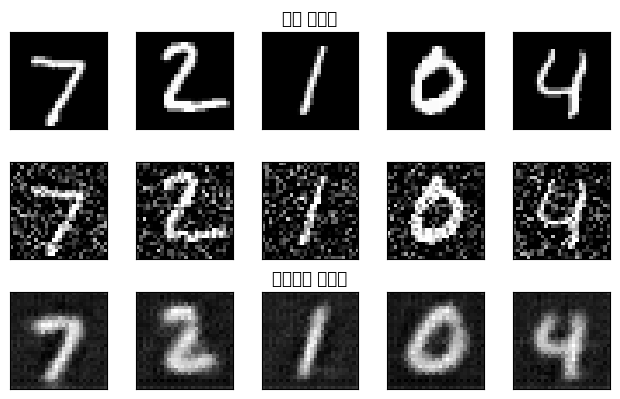

EPOCH 2/30

 EPOCH 2/30 	 train loss 0.055 	 val loss 0.045


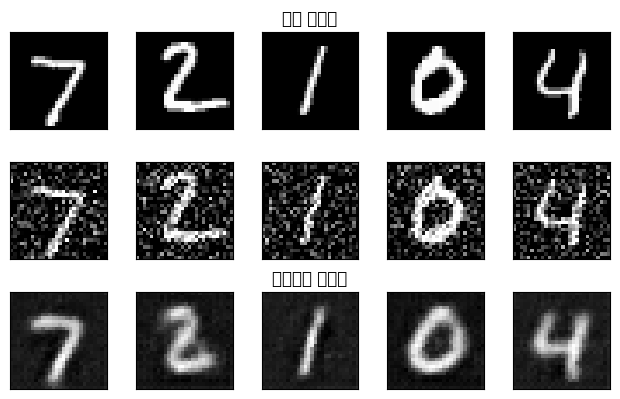

EPOCH 3/30



 EPOCH 3/30 	 train loss 0.053 	 val loss 0.042


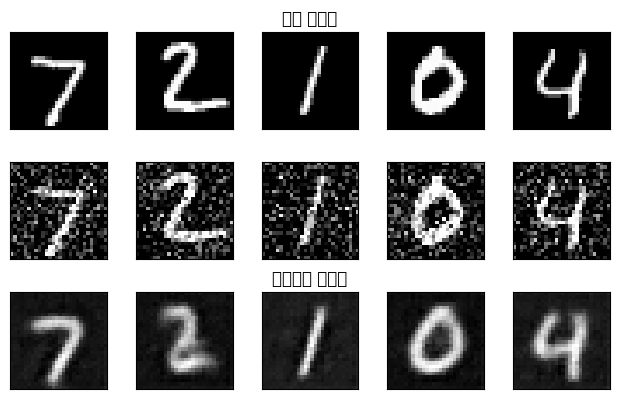

EPOCH 4/30



 EPOCH 4/30 	 train loss 0.052 	 val loss 0.042


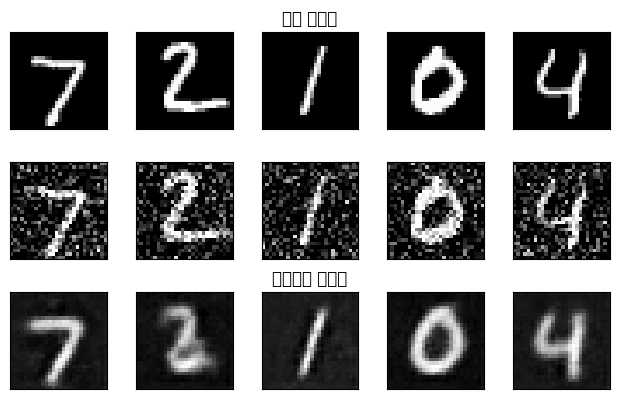

EPOCH 5/30

 EPOCH 5/30 	 train loss 0.052 	 val loss 0.041


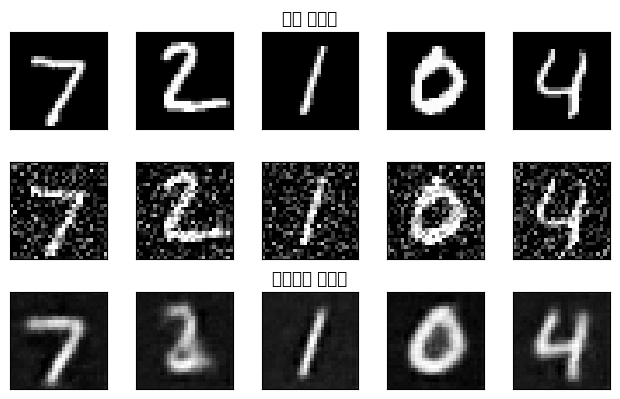

EPOCH 6/30



 EPOCH 6/30 	 train loss 0.051 	 val loss 0.041


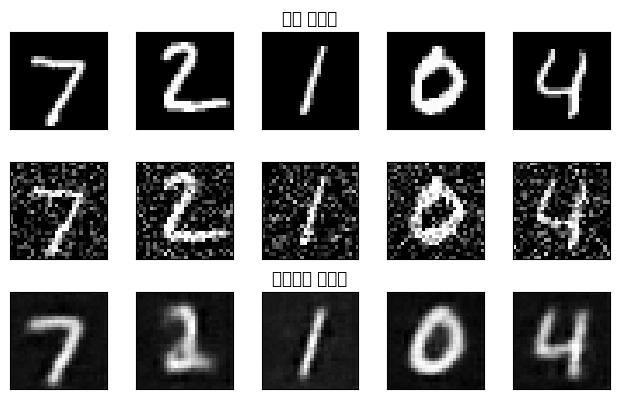

EPOCH 7/30

 EPOCH 7/30 	 train loss 0.051 	 val loss 0.040


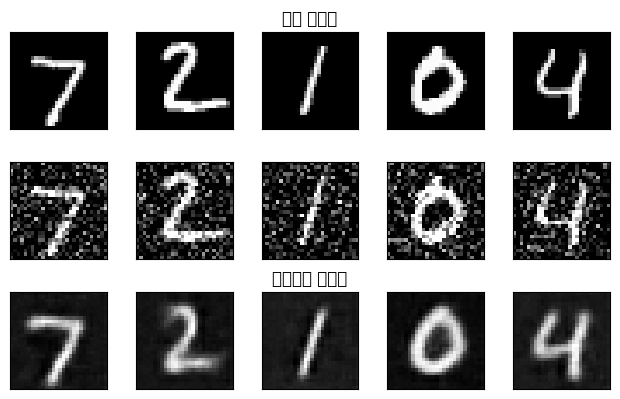

EPOCH 8/30



 EPOCH 8/30 	 train loss 0.051 	 val loss 0.040


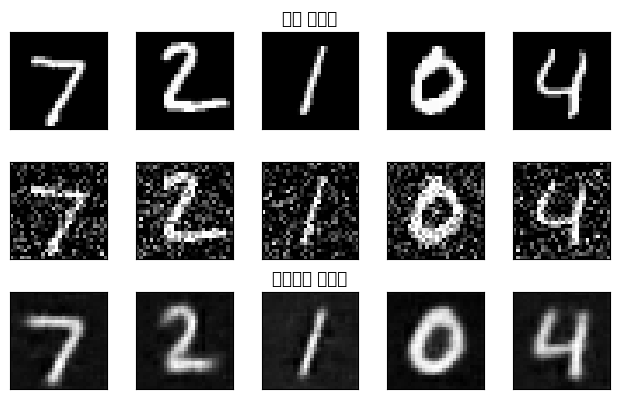

EPOCH 9/30



 EPOCH 9/30 	 train loss 0.051 	 val loss 0.040


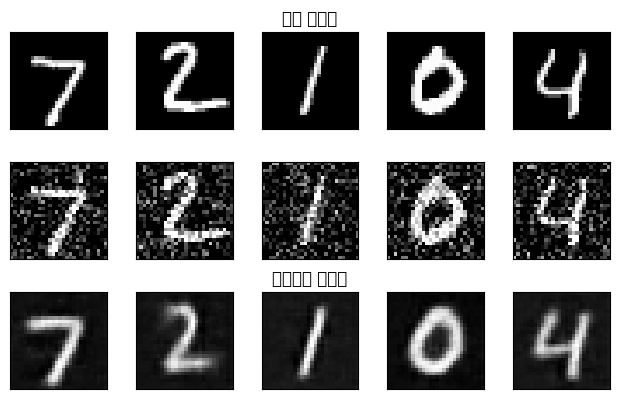

EPOCH 10/30



 EPOCH 10/30 	 train loss 0.051 	 val loss 0.039


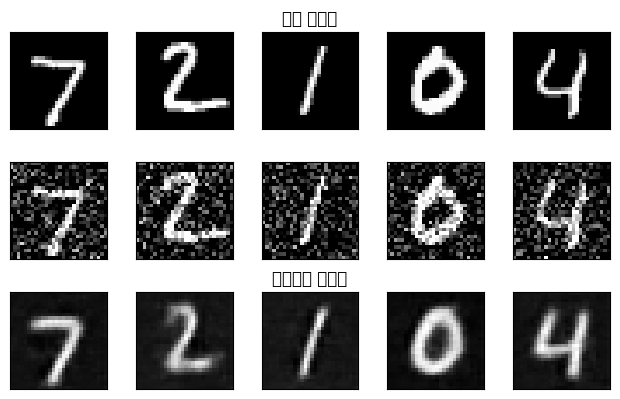

EPOCH 11/30



 EPOCH 11/30 	 train loss 0.050 	 val loss 0.039


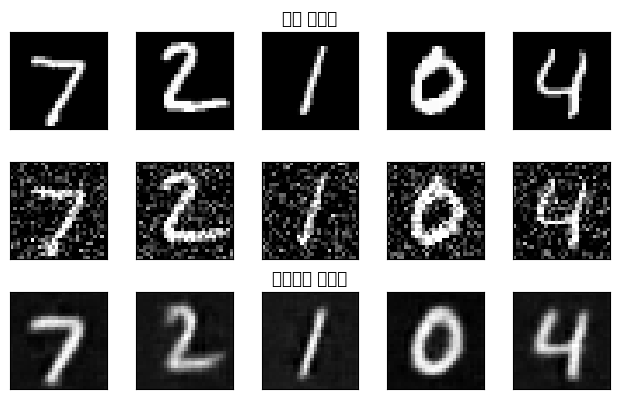

EPOCH 12/30



 EPOCH 12/30 	 train loss 0.050 	 val loss 0.039


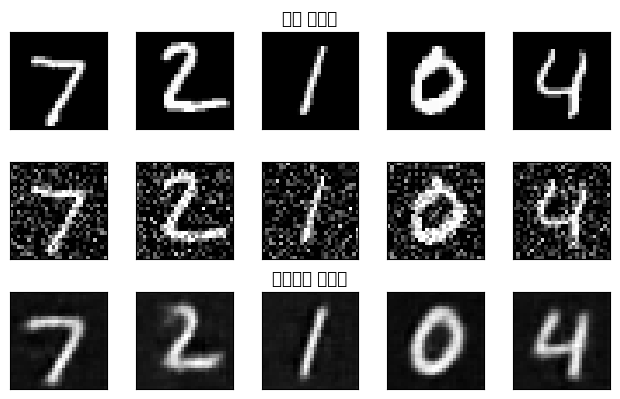

EPOCH 13/30



 EPOCH 13/30 	 train loss 0.050 	 val loss 0.039


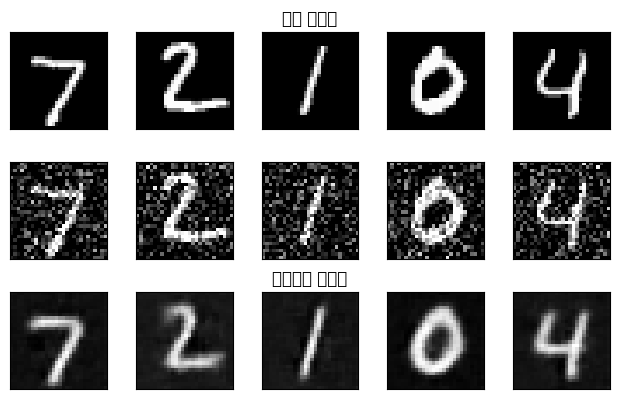

EPOCH 14/30



 EPOCH 14/30 	 train loss 0.050 	 val loss 0.039


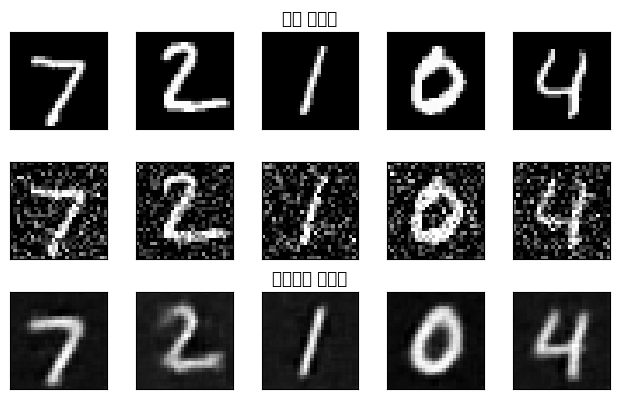

EPOCH 15/30



 EPOCH 15/30 	 train loss 0.050 	 val loss 0.039


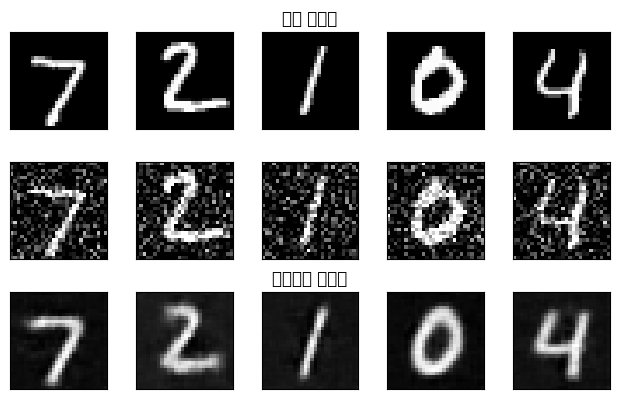

EPOCH 16/30



 EPOCH 16/30 	 train loss 0.050 	 val loss 0.039


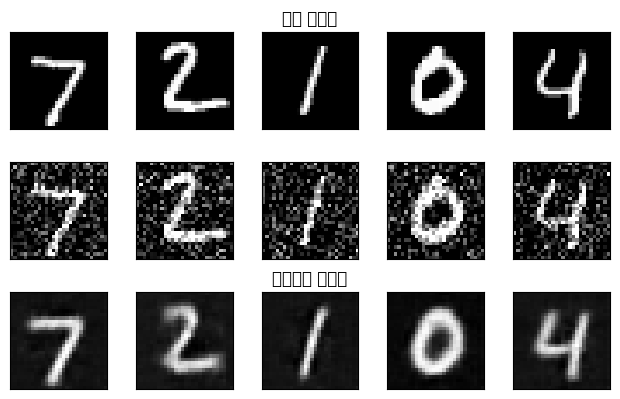

EPOCH 17/30



 EPOCH 17/30 	 train loss 0.050 	 val loss 0.039


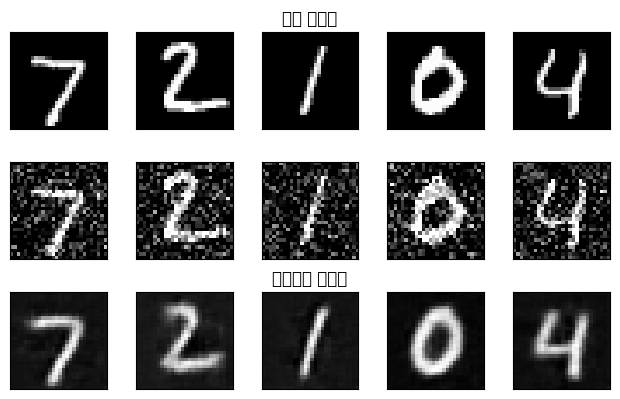

EPOCH 18/30



 EPOCH 18/30 	 train loss 0.050 	 val loss 0.038


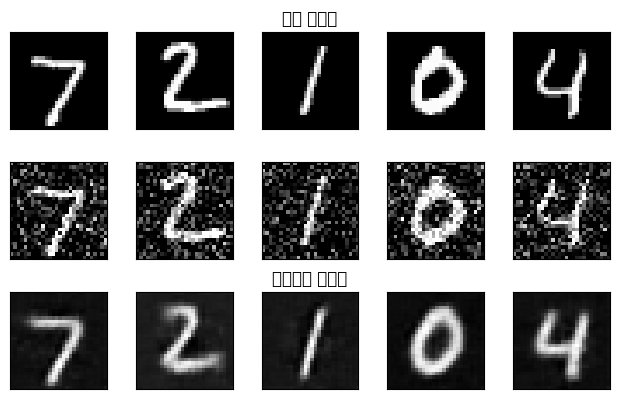

EPOCH 19/30



 EPOCH 19/30 	 train loss 0.050 	 val loss 0.038


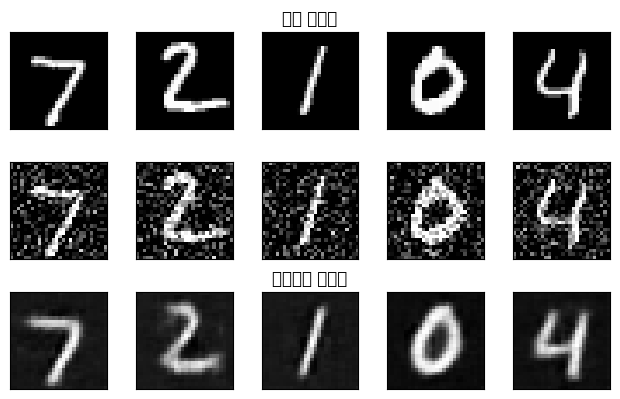

EPOCH 20/30



 EPOCH 20/30 	 train loss 0.050 	 val loss 0.039


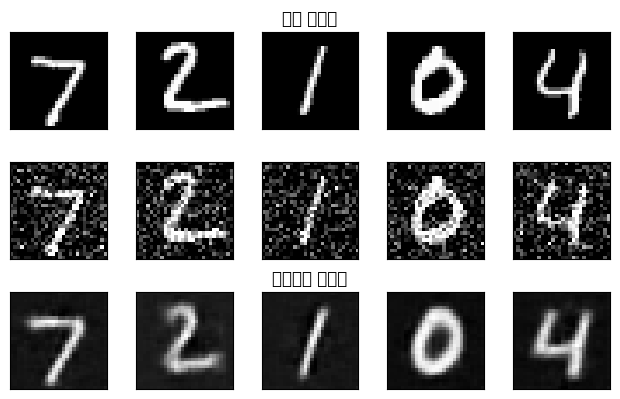

EPOCH 21/30



 EPOCH 21/30 	 train loss 0.050 	 val loss 0.038


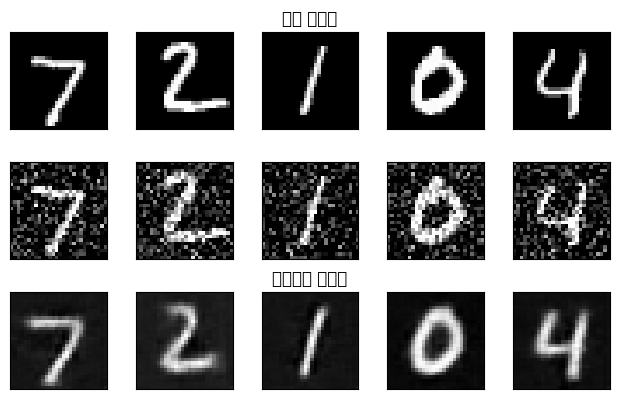

EPOCH 22/30



 EPOCH 22/30 	 train loss 0.050 	 val loss 0.038


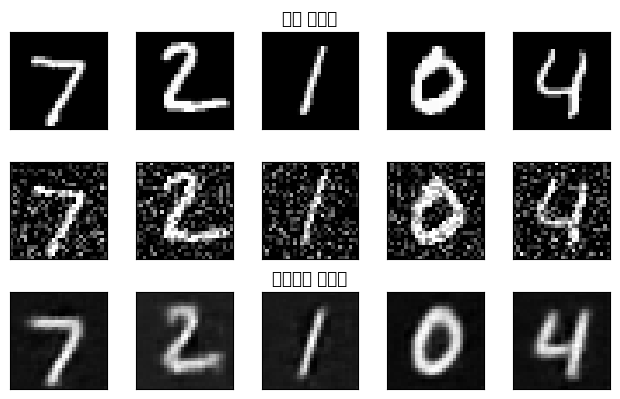

EPOCH 23/30



 EPOCH 23/30 	 train loss 0.050 	 val loss 0.038


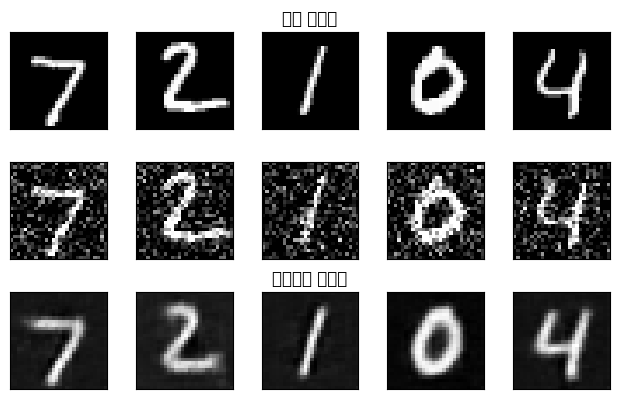

EPOCH 24/30



 EPOCH 24/30 	 train loss 0.050 	 val loss 0.038


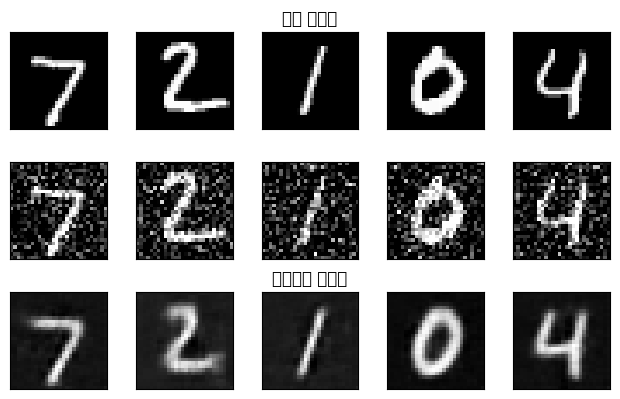

EPOCH 25/30



 EPOCH 25/30 	 train loss 0.050 	 val loss 0.038


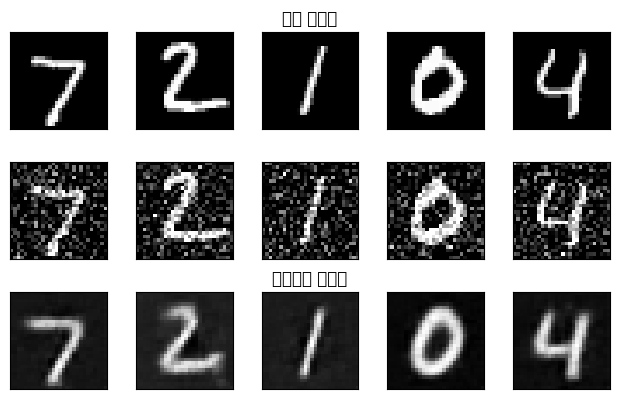

EPOCH 26/30



 EPOCH 26/30 	 train loss 0.050 	 val loss 0.038


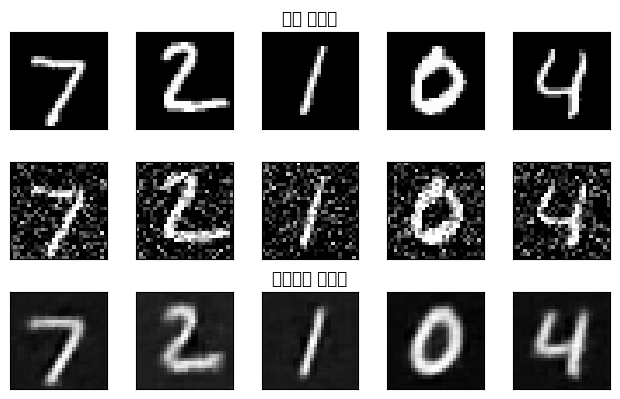

EPOCH 27/30



 EPOCH 27/30 	 train loss 0.049 	 val loss 0.037


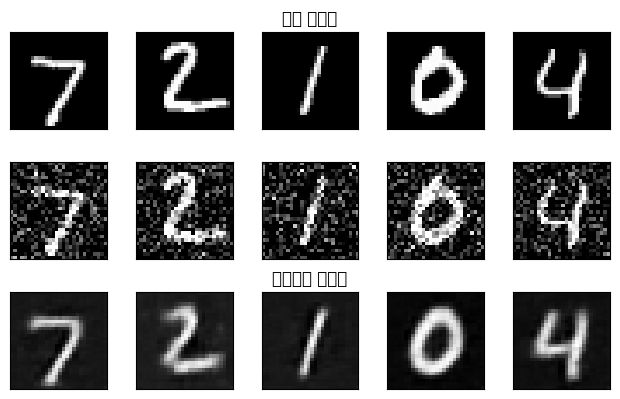

EPOCH 28/30



 EPOCH 28/30 	 train loss 0.049 	 val loss 0.038


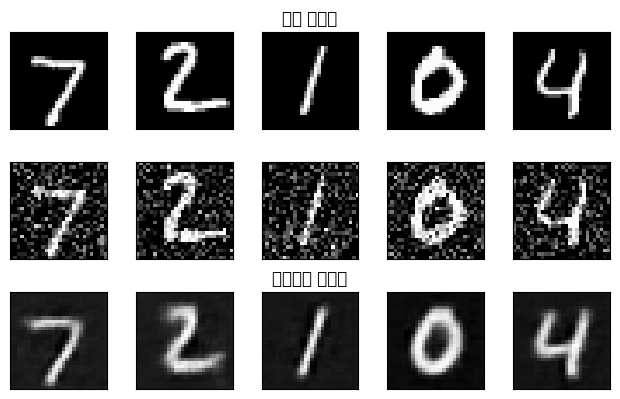

EPOCH 29/30



 EPOCH 29/30 	 train loss 0.049 	 val loss 0.038


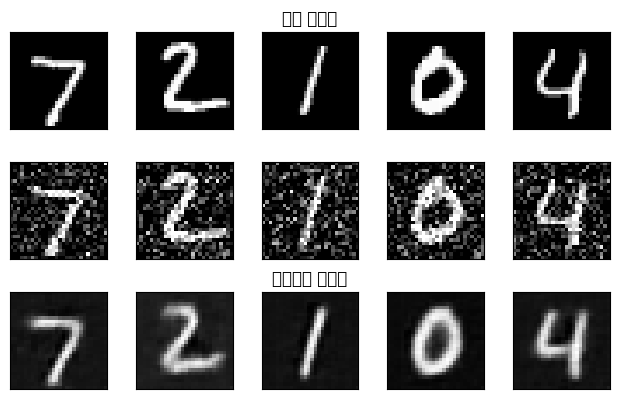

EPOCH 30/30

 EPOCH 30/30 	 train loss 0.049 	 val loss 0.038


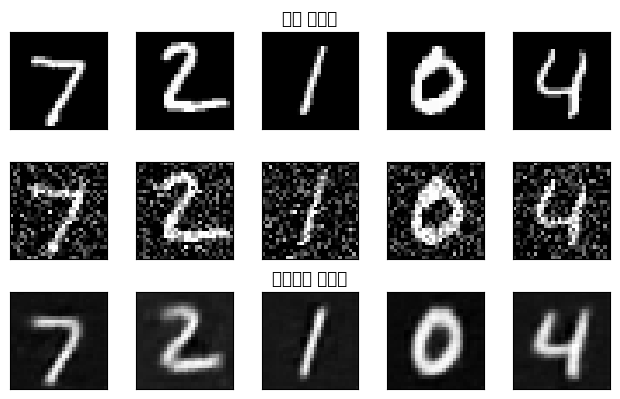

In [24]:
import numpy as np

num_epochs = 30
history_da = {'train_loss':[], 'val_loss': []}
loss_fn = torch.nn.MSELoss()

for epoch in range(num_epochs):
  print('EPOCH %d/%d' % (epoch + 1, num_epochs))
  train_loss = train_epoch(
      encoder = encoder,
      decoder = decoder,
      device = device,
      dataloader = train_loader,
      loss_fn = loss_fn,
      optimizer = optim, noise_factor = 0.3) # 모델 학습 함수(train_epoch)를 이용하여 모델 학습
  val_loss = test_epoch(
      encoder = encoder, decoder = decoder,
      device = device, dataloader = test_loader,
      loss_fn = loss_fn, noise_factor = 0.3) # 모델 검증(테스트) 함수(test_epoch)를 이용하여 테스트
  history_da['train_loss'].append(train_loss)
  history_da['val_loss'].append(val_loss)
  print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1,
                                                                        num_epochs, train_loss, val_loss))
  plot_ae_outputs(encoder, decoder, noise_factor = 0.3)

에포크가 진행될수록 훈련과 검증(태스트) 데이터셋에 대한 오차가 줄어들고 있습니다. 또한, 노이즈를 이용하여 생성된 이미지 역시 선명해지는 것을 확인할 수 있습니다.

지금까지 오토인코더 예제를 살펴보았다면 이제 변형 오토인코더를 살펴봅시다.

### 13.2.2 변형 오토인코더
변형 오토인코더를 좀 더 쉽게 이해할 수 있게 오토인코더와 비교하면서 설명하겠습니다. 오토인코더는 다음 그림과 같이 입력(숫자 2)->인코더->압축(차원축소)->디코더->출력(숫자 2)이 나오게 하는 방법입니다.

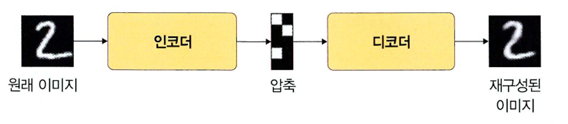

오토인코더는 차원을 줄이는 것이 목표이기 때문에 새롭게 생성된 데이터의 확률 분포에는 관심이 없습니다.

반면 변형 오토인코더는 표준편차와 평균을 이용하여 확률 분포를 만들고, 거기에서 샘플링하여 디코더를 통과시킨 후 새로운 데이터를 만들어 법니다. 즉, 변형 오토인코더는 입력 데이터와 조금 다른 출력 데이터를 만들어 내는데, 이때 z라는 가우시안 분포를 이용합니다(z를 잠재 벡터라고 합니다). 중요한 특성의 파라미터를 담고 있는 z 분포에서 벡터를 랜덤하게 샘플링하고 이 분포의 오치를이용하여 입력 데이터와 유사한 다양한 데이터를 만들어 내는 것이 변형 오토인코더입니다.

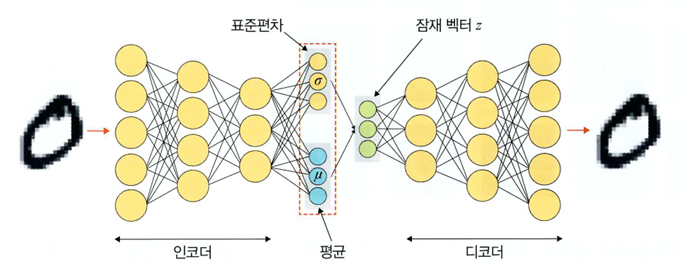

오토인코더는 데이터 벡터에 대한 차원을 축소하여 실제 이미지와 동일한 이미지를 출력하는 것이 목적이었다면, 변형 오토인코더는 데이터가 만들어지는 확률 분포를 찾아 비슷한 데이터를 생성하는 것이 목적입니다.

변형 오토인코더에서 인코더와 디코더에 대한 네트워크는 다음 그림과 같습니다.

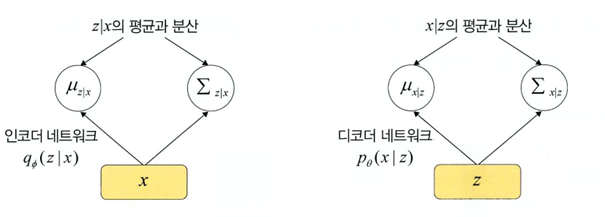

그럼 인코더 네트워크부터 자세히 살펴보겠습니다.

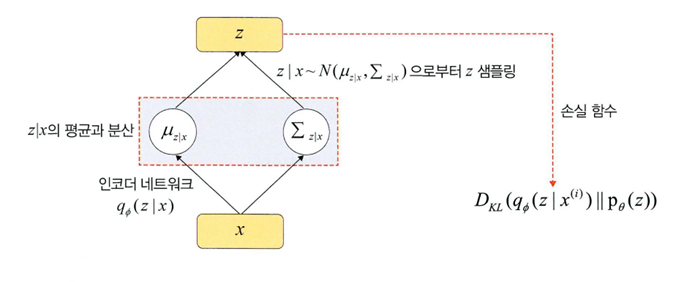

디코더 네트워크를 살펴보겠습니다.

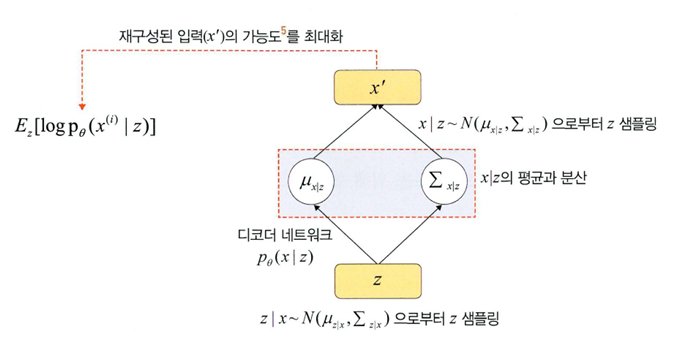

텐서보드 엑스는 학습 과정을 시각적으로 확인하고자 할 때 사용하는 도구입니다.

변형 오토인코더에서도 오토인코더에서와 마찬가지로 MNIST 데이터셋을 이용합니다. 먼저 필요한 라이브러리를 호출합니다.

In [26]:
import datetime
import os
from tensorboardX import SummaryWriter

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MNIST 데이터셋을 내려받은 후 이미지를 텐서로 변환합니다.

In [27]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='../chap13/data', train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root='../chap13/data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True, num_workers=4, pin_memory=False)

test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 434kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.05MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


모델의 네트워크를 생성합니다. 네트워크는 오토인코더처럼 인코더와 디코더로 구성됩니다.

In [28]:
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super(Encoder, self).__init__()
    self.input1 = nn.Linear(input_dim, hidden_dim)
    self.input2 = nn.Linear(hidden_dim, hidden_dim)
    self.mean = nn.Linear(hidden_dim, latent_dim)
    self.var = nn.Linear(hidden_dim, latent_dim)

    self.LeakyReLU = nn.LeakyReLU(0.2)
    self.training = True

  def forward(self, x):
    h_ = self.LeakyReLU(self.input1(x))
    h_ = self.LeakyReLU(self.input2(h_))
    mean = self.mean(h_)
    log_var = self.var(h_)
    return mean, log_var # 인코더 네트워크에서 평균과 분산을 반환

인코더 역할은 데이터(x)가 주어졌을 때 디코더가 원래 데이터로 잘 복원할 수 있는 이상적인 확률분포p(zIx)를 찾는 것입니다. 변형 오토인코더에서는 이상적인 확률분포를 찾는데 변분추론을 사용합니다.

이번에는 디코더 네트워크를 정의합니다.

In [29]:
class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super(Decoder, self).__init__()
    self.hidden1 = nn.Linear(latent_dim, hidden_dim)
    self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
    self.output = nn.Linear(hidden_dim, output_dim)
    self.LeakyReLU = nn.LeakyReLU(0.2)

  def forward(self, x):
    h = self.LeakyReLU(self.hidden1(x))
    h = self.LeakyReLU(self.hidden2(h))
    x_hat = torch.sigmoid(self.output(h))
    return x_hat # 디코더 결과는 시그모이드를 통과했으므로 0~1 값을 갖습니다.

디코더는 추출한 샘플을 입력으로 받아 다시 원본으로 재구축(재생성)하는 역할을 수행합니다.

이제 평균과 표준편차가 주어졌을 때 잠재 벡터 Z를 만들기 위해 reparameterization()이라는 이름으로 함수를 생성해 보겠습니다.

In [30]:
class Model(nn.Module):
  def __init__(self, Encoder, Decoder):
    super(Model, self).__init__()
    self.Encoder = Encoder
    self.Decoder = Decoder

  def reparameterization(self, mean, var):
    epsilon = torch.randn_like(var).to(device)
    z = mean + var * epsilon
    return z

  def forward(self, x):
    mean, log_var = self.Encoder(x)
    z = self.reparameterization(mean, torch.exp(0.5 * log_var))
    x_hat = self.Decoder(z)
    return x_hat, mean, log_var

필요한 모델의 네트워크(인코더와 디코더) 객체를 초기화합니다.

In [31]:
x_dim = 784
hidden_dim = 400
latent_dim = 200
epochs = 30
batch_size = 100

encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)

오차를 계산하기 위한 손실 함수를 정의합니다.

In [32]:
def loss_function(x, x_hat, mean, log_var):
  reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
  KLD = -0.5*torch.sum(1+log_var-mean.pow(2)-log_var.exp())
  return reproduction_loss, KLD

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

이제 모델 학습에 필요한 함수를 정의합니다.

In [33]:
saved_loc = 'scalar/' # 텐서보드에서 사용할 경로
writer = SummaryWriter(saved_loc)

model.train()
def train(epoch, model, train_loader, optimizer):
  train_loss = 0
  for batch_idx, (x, _) in enumerate(train_loader):
    x = x.view(batch_size, x_dim)
    x = x.to(device)

    optimizer.zero_grad()
    x_hat, mean, log_var = model(x)
    BCE, KLD = loss_function(x, x_hat, mean, log_var)
    loss = BCE + KLD
    writer.add_scalar("Train/Reconstruction Error", BCE.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/KL-Divergence", KLD.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    writer.add_scalar("Train/Total Loss", loss.item(), batch_idx + epoch *
                      (len(train_loader.dataset)/batch_size))
    train_loss += loss.item()
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
      print('Train Epoch: {} [{}/{} ({:.0f}%)]\t Loss: {:.6f}'.format(
          epoch, batch_idx * len(x), len(train_loader.dataset),
          100. * batch_idx / len(train_loader), loss.item() / len(x)))
  print('====> Epoch: {} Average loss: {:.4f}'.format(
      epoch, train_loss / len(train_loader.dataset)))

테스트 데이터셋을 이용해서 모델을 평가하기 위한 함수를 정의합니다.

In [34]:
def test(epoch, model, test_loader):
  model.eval()
  test_loss = 0
  with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
      x = x.view(batch_size, x_dim)
      x = x.to(device)
      x_hat, mean, log_var = model(x)
      BCE, KLD = loss_function(x, x_hat, mean, log_var)
      loss = BCE + KLD

      writer.add_scalar("Test/Reconstruction Error", BCE.item(), batch_idx +
                        epoch * (len(test_loader.dataset)/batch_size)) # 테스트 데이터셋에 대해서도 오차를 로그에 저장
      writer.add_scalar("Test/KL-Divergence", KLD.item(), batch_idx + epoch *
                        (len(test_loader.dataset)/batch_size))
      writer.add_scalar("Test/Total Loss", loss.item(), batch_size + epoch *
                        (len(test_loader.dataset)/batch_size))
      test_loss += loss.item()

      if batch_idx == 0:
        n = min(x.size(0), 8)
        comparison = torch.cat([x[:n], x_hat.view(batch_size, x_dim)[:n]])
        grid = torchvision.utils.make_grid(comparison.cpu())
        writer.add_image("Test image - Above: Real data, below: reconstruction data", grid, epoch)

이제 모델을 학습시킵니다.

In [35]:
from tqdm import tqdm
for epoch in tqdm(range(0, epochs)):
  train(epoch, model, train_loader, optimizer)
  test(epoch, model, test_loader)
  print("\n")
writer.close()

  0%|          | 0/30 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Epoch: 0 [0/60000 (0%)]	 Loss: 543.581641
Train Epoch: 0 [10000/60000 (17%)]	 Loss: 195.890586
Train Epoch: 0 [20000/60000 (33%)]	 Loss: 177.247168
Train Epoch: 0 [30000/60000 (50%)]	 Loss: 157.348652
Train Epoch: 0 [40000/60000 (67%)]	 Loss: 157.219541
Train Epoch: 0 [50000/60000 (83%)]	 Loss: 144.957715
====> Epoch: 0 Average loss: 172.7833


  3%|▎         | 1/30 [00:29<14:07, 29.21s/it]



Train Epoch: 1 [0/60000 (0%)]	 Loss: 140.954863
Train Epoch: 1 [10000/60000 (17%)]	 Loss: 140.022803
Train Epoch: 1 [20000/60000 (33%)]	 Loss: 131.740908
Train Epoch: 1 [30000/60000 (50%)]	 Loss: 127.537852
Train Epoch: 1 [40000/60000 (67%)]	 Loss: 121.348301
Train Epoch: 1 [50000/60000 (83%)]	 Loss: 121.061621
====> Epoch: 1 Average loss: 128.3542


  7%|▋         | 2/30 [00:54<12:41, 27.19s/it]

...

 93%|█████████▎| 28/30 [12:40<00:57, 28.76s/it]



Train Epoch: 28 [0/60000 (0%)]	 Loss: 100.321797
Train Epoch: 28 [10000/60000 (17%)]	 Loss: 97.721523
Train Epoch: 28 [20000/60000 (33%)]	 Loss: 100.640352
Train Epoch: 28 [30000/60000 (50%)]	 Loss: 99.425547
Train Epoch: 28 [40000/60000 (67%)]	 Loss: 97.437871
Train Epoch: 28 [50000/60000 (83%)]	 Loss: 102.773291
====> Epoch: 28 Average loss: 100.2962


 97%|█████████▋| 29/30 [13:09<00:28, 28.65s/it]



Train Epoch: 29 [0/60000 (0%)]	 Loss: 101.734365
Train Epoch: 29 [10000/60000 (17%)]	 Loss: 99.600410
Train Epoch: 29 [20000/60000 (33%)]	 Loss: 96.659805
Train Epoch: 29 [30000/60000 (50%)]	 Loss: 98.689902
Train Epoch: 29 [40000/60000 (67%)]	 Loss: 103.456025
Train Epoch: 29 [50000/60000 (83%)]	 Loss: 99.079600
====> Epoch: 29 Average loss: 100.1675


100%|██████████| 30/30 [13:37<00:00, 27.25s/it]

이제 텐서보드에서 오차가 변화되는 과정을 살펴봅시다.

In [36]:
%load_ext tensorboard
%tensorboard --logdir scalar --port = 6013

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
2026-05-24 09:17:38.038885: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-24 09:17:39.662163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--insp

오차 결과 KLD와 재구성 오차가 반비례하면서 전체 오차는 에포크가 진행될수록 작아지는 것을 확인할 수 있습니다. 재구성 오차가 감소하고 있는 것으로 보아 기존 이미지를 이용한 새로운 이미지 생성이 잘 진행되고 있음을 유추해 볼 수 있습니다.

훈련 데이터셋과 마찬가지로 KLD와 재구성 오치는 반비례 관계를 가지며 전체 오차는 에포크가 진행되면서 줄어들고 있습니다. 기존 이미지를 이용한 새로운 이미지가 잘 생성되고 있음을 의미합니다.